# 4.0.1 — inspect the dynamic HMM fits

Viewer for whatever `4.0_hmm_dynamic.ipynb` has already produced. **Nothing here refits**
— it reads the pickles, which already contain `most_likely_states`, the per-fold LL table,
the lag profile and every selection step. So it runs in seconds and can be opened while a
fitting job is still going, on however many sessions are done so far.

This is the equivalent of 4.2's *"sessions available to process"* + per-session plots,
except 4.2 had to re-initialise a model and re-decode the states just to look at one
session, which made inspection as expensive as fitting.

All the plotting lives in `hmm_dynamic_plots.py`.

| panel | what it answers |
|---|---|
| segmentation | is the fit behaviourally sensible? (the only check the numbers can't make) |
| lag profile | what a naive argmax would have chosen — context |
| cohort / statistics | lag distribution, dwell, bits, failure screens, and the relationships between them |

In [23]:
""" IMPORTS """
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import sys
# these notebooks now live in hmm_diagnostics/intermediate_pipeline/, so the
# shared segmentation_functions.py is two levels up
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))   # nothing here needs a GPU; silences the probe
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hmm_dynamic_functions as H
import hmm_dynamic_plots as P

%matplotlib inline

## Parameters — must match the run you want to look at

In [24]:
prefix = '/home/ines/repositories/representation_learning_variability/'

# ---- WHICH RUN (mirror 4.0's config cell) ------------------------------------
data_path = prefix + 'paper-individuality/data/design_matrices/'
# data_path = prefix + 'paper-individuality/data/design_matrices/1_camera_setup/session_1/'

fps = 60.0

var_interest = ['whisker_me']
# var_interest = ['Lick count']
# var_interest = ['avg_wheel_vel']

num_states = 2
num_train_batches = 5
method = 'prior'
fit_method = 'em'
zsc = (var_interest == ['whisker_me'])

fitting_params = f'{num_train_batches}_{method}_{fit_method}_zsc_{zsc}_dynamic/'
save_path = prefix + 'paper-individuality/data/hmm/grid_search_dynamic/' + fitting_params
csv_path = os.path.join(save_path, f'assessments_{var_interest[0]}.csv')

# ---- the PREVIOUS pipeline's output, for comparison (4.1 + 4.2) ---------------
# used by compare_lag='legacy': the lag your old code selected is read out of these files
legacy_params = f'{num_train_batches}_{method}_{fit_method}_zsc_{zsc}/'
legacy_path = prefix + 'paper-individuality/data/hmm/most_likely_states/' + legacy_params

print('reading:', save_path)
print('legacy :', legacy_path, '(exists)' if os.path.exists(legacy_path) else '(NOT FOUND)')

reading: /home/ines/repositories/representation_learning_variability/paper-individuality/data/hmm/grid_search_dynamic/5_prior_em_zsc_True_dynamic/
legacy : /home/ines/repositories/representation_learning_variability/paper-individuality/data/hmm/most_likely_states/5_prior_em_zsc_True/ (exists)


## Sessions available

In [25]:
# What is finished. Reads the save directory, so it works mid-run.
sessions_available = P.available_sessions(save_path, var_interest)
print(f"Found {len(sessions_available)} finished sessions.")

# The assessment table, rebuilt from the pickles (so it is complete even if the run was
# interrupted and restarted -- the CSV written by run_all is the same thing).
df = H.assessments_from_pickles(save_path, var_interest)

cols = [c for c in ['mouse', 'eid', 'n_frames', 'tau', 'cap', 'best_lag', 'at_cap',
                    'median_dwell_ms', 'n_segments', 'occupancy_state1', 'bits_LL',
                    'fit_ok'] if c in df]
df[cols]

Found 342 finished sessions.


,mouse,eid,n_frames,tau,cap,best_lag,at_cap,median_dwell_ms,n_segments,occupancy_state1,bits_LL,fit_ok
0,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,227390,32.0,32,8,False,550.000000,4197,0.4206,1.765426,True
1,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,316910,33.0,32,8,False,400.000000,6658,0.5912,1.243500,True
2,CSHL045,7939711b-8b4d-4251-b698-b97c1eaa846e,404530,23.0,32,8,False,308.333333,10472,0.6783,0.825389,True
3,CSHL045,dfd8e7df-dc51-4589-b6ca-7baccfeb94b4,343090,49.0,64,32,False,216.666667,9438,0.4593,1.749582,True
4,CSHL045,fa704052-147e-46f6-b190-a65b837e605e,347175,30.0,32,32,True,383.333333,8048,0.5853,1.422561,True
...,...,...,...,...,...,...,...,...,...,...,...,...
337,ibl_witten_29,af55d16f-0e31-4073-bdb5-26da54914aa2,420205,43.0,32,32,True,466.666667,7413,0.4751,1.877461,True
338,ibl_witten_29,d2832a38-27f6-452d-91d6-af72d794136c,301575,41.0,32,8,False,533.333333,4596,0.5212,1.328280,True
339,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,290050,77.0,64,64,True,500.000000,4054,0.4891,1.684155,True
340,ibl_witten_32,08102cfc-a040-4bcf-b63c-faa0f4914a6f,325050,58.0,64,64,True,266.666667,8373,0.3336,1.889945,True


In [26]:
# Quick counts, same three independent screens as 4.0's review cell
if len(df):
    for flag in ['collapsed', 'degenerate_occupancy', 'flickering']:
        if flag in df:
            print(f'  {flag:22s} {int(df[flag].fillna(False).sum()):4d}')
    print(f"  {'at the lag cap':22s} {int(df.at_cap.fillna(False).sum()) if 'at_cap' in df else 0:4d}")
    print(f"  {'fit_ok':22s} {int(df.fit_ok.sum()):4d} / {len(df)}")
    if 'best_lag' in df:
        print('\nselected lag:')
        print(df.best_lag.value_counts().sort_index().to_string())
    print('\nmedian dwell (ms):', round(df.median_dwell_ms.median(), 1))

  collapsed                 0
  degenerate_occupancy      0
  flickering                7
  at the lag cap          172
  fit_ok                  335 / 342

selected lag:
best_lag
1       11
2        4
4        2
8      109
16      49
32     133
64      31
128      3

median dwell (ms): 400.0


## Cohort overview

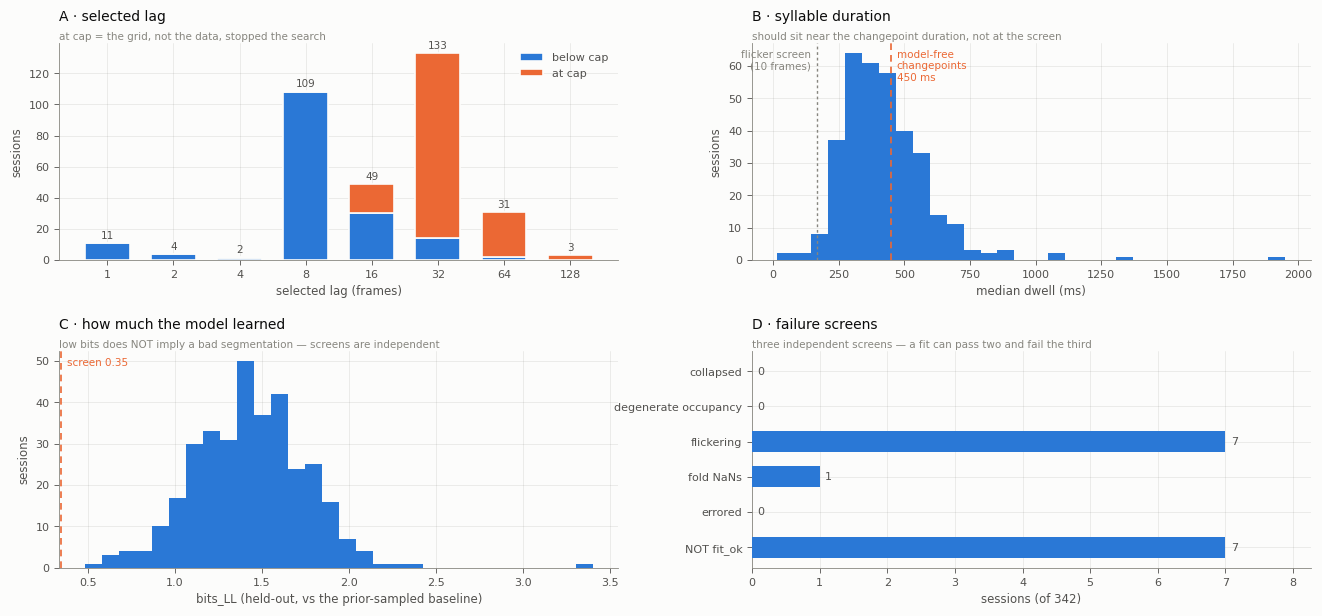

In [27]:
fig = P.plot_cohort(df, fps=fps)
plt.show()

## Fit statistics from the CSV

`run_all` writes `assessments_<var>.csv` in `save_path`, rebuilt from every pickle on disk
(so it survives an interrupted run). This section reads that file — the numbers here are
the ones a reviewer would be shown.

Panel **E** is the one to take seriously for an individuality paper: if the selected lag
clusters by mouse it is a trait, and per-session selection is the right choice; if it
scatters within mouse as much as between, it is fold noise and one pooled value would do.

In [28]:
if os.path.exists(csv_path):
    stats = pd.read_csv(csv_path)
    print(f'{csv_path}\n{len(stats)} rows')
else:
    # no call of run_all has finished yet -- rebuild the same table from the pickles
    stats = df
    print(f'no CSV yet, using the {len(stats)} pickles on disk')

num = [c for c in ['n_frames', 'tau', 'cap', 'best_lag', 'median_dwell_ms',
                   'mean_dwell_frames', 'n_segments', 'occupancy_state1',
                   'raw_ll_per_frame', 'bits_LL'] if c in stats]
stats[num].describe().T

/home/ines/repositories/representation_learning_variability/paper-individuality/data/hmm/grid_search_dynamic/5_prior_em_zsc_True_dynamic/assessments_whisker_me.csv
342 rows


,count,mean,std,min,25%,50%,75%,max
n_frames,342.0,275509.093567,58659.873022,102740.000000,240785.000000,267592.500000,314305.000000,438395.000000
tau,335.0,51.271642,114.344582,4.000000,28.500000,37.000000,48.000000,1958.000000
cap,342.0,47.812865,40.355750,4.000000,32.000000,32.000000,64.000000,256.000000
best_lag,342.0,24.289474,19.534640,1.000000,8.000000,16.000000,32.000000,128.000000
median_dwell_ms,342.0,426.291423,177.800628,16.666667,316.666667,400.000000,516.666667,1950.000000
mean_dwell_frames,342.0,53.032699,21.528166,3.140149,40.523214,48.935685,59.342102,238.618123
n_segments,342.0,6136.698830,5847.422646,844.000000,4339.000000,5641.000000,6905.500000,80751.000000
occupancy_state1,342.0,0.510590,0.106097,0.019400,0.442500,0.504350,0.577375,0.779400
raw_ll_per_frame,342.0,-0.133294,0.243741,-0.902972,-0.291059,-0.138141,0.019932,1.126994
bits_LL,342.0,1.435677,0.328102,0.483981,1.220676,1.424155,1.641605,3.402560


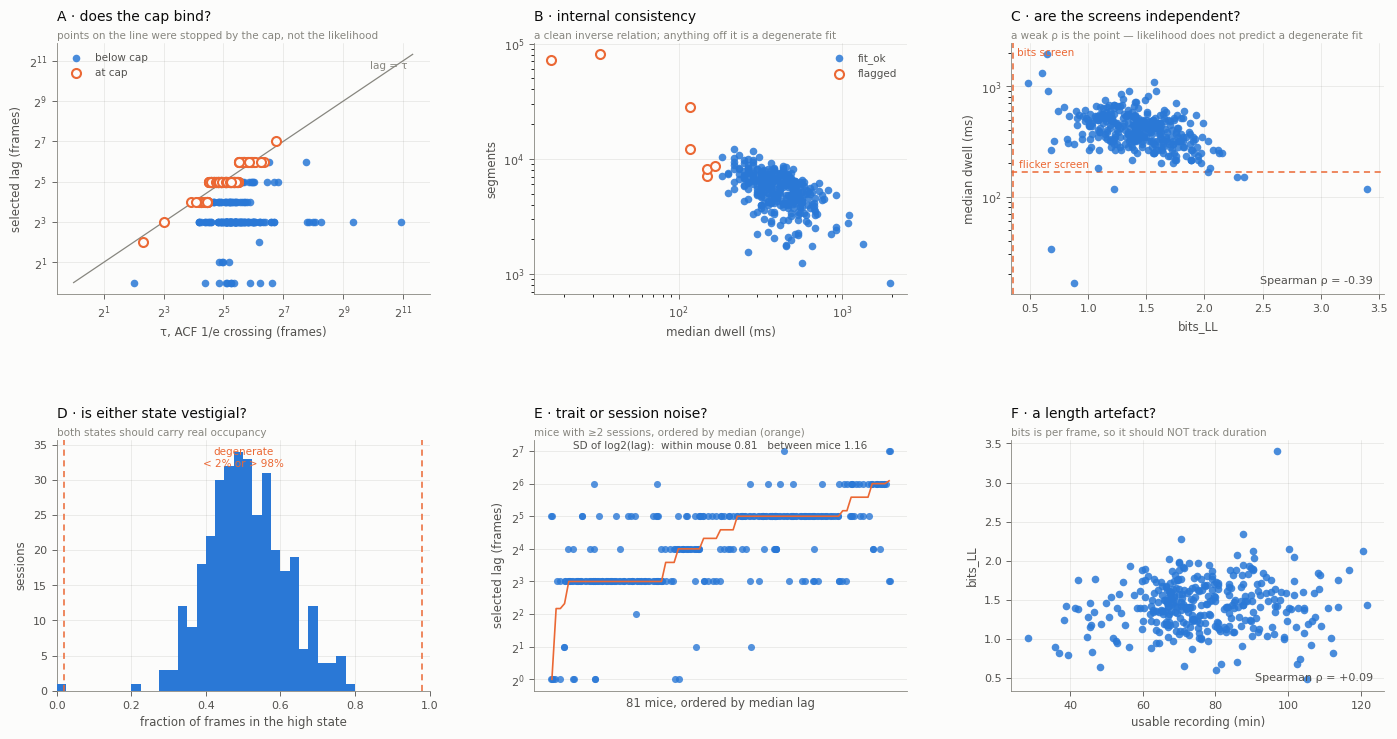

In [29]:
fig = P.plot_fit_statistics(stats, fps=fps)
plt.show()

In [30]:
# Per-mouse summary: how consistent is a mouse across its own sessions?
if 'mouse' in stats and 'best_lag' in stats:
    per_mouse = (stats.groupby('mouse')
                 .agg(n=('eid', 'count'),
                      lag_median=('best_lag', 'median'),
                      lag_min=('best_lag', 'min'),
                      lag_max=('best_lag', 'max'),
                      dwell_ms=('median_dwell_ms', 'median'),
                      bits=('bits_LL', 'median'),
                      flagged=('fit_ok', lambda s: int((~s.fillna(False)).sum())))
                 .sort_values('n', ascending=False))
    display(per_mouse)

    multi = per_mouse[per_mouse.n >= 2]
    same = int((multi.lag_min == multi.lag_max).sum())
    print(f'{same}/{len(multi)} mice with >=2 sessions selected the SAME lag every time')

,n,lag_median,lag_min,lag_max,dwell_ms,bits,flagged
mouse,,,,,,,
PL033,16,32.0,16,32,475.000000,1.476415,0
ibl_witten_29,9,8.0,8,64,483.333333,1.673324,0
DY_009,9,8.0,1,64,316.666667,1.541457,0
DY_020,8,32.0,8,32,358.333333,1.557067,0
PL030,8,32.0,32,32,412.500000,1.514256,0
...,...,...,...,...,...,...,...
ZFM-02373,1,32.0,32,32,333.333333,1.621110,0
ZM_2245,1,32.0,32,32,566.666667,1.645854,0
ibl_witten_25,1,64.0,64,64,266.666667,1.010087,0


21/81 mice with >=2 sessions selected the SAME lag every time


## One session in detail

Give an **eid** — the 8-character prefix is enough, the mouse name is looked up for you —
and optionally `start_s` to move the window elsewhere in the session. Rerun the cell with
a different `start_s` to walk through the recording.

`compare_lag='legacy'` overlays **the lag your previous code selected**, read out of the old
`most_likely_states` files. Both segmentations get a ribbon, disagreeing frames are shaded
orange, and with no `start_s` the window centres on the **largest disagreement** — the
honest place to look.

Two things it does deliberately:

- It re-decodes at the old lag on the **current** data rather than loading the old state
  array. The NaN-handling fix changed which rows survive, so for 163 of 319 sessions the
  old sequence is a *different length* and would silently misalign. This keeps the
  comparison frame-exact and isolates the selection rule from the data fix.
- The old grid was `[1, 10, 20, 30, 40]`, which shares only the value 1 with the new
  doubling grid, so an old lag of 20 is compared at the nearest fitted lag (16) and the
  ribbon is labelled `old 20->16`.

For reference: the old rule chose **lag 1 in 312 of 319 sessions**, so this is usually —
but not always — the same as `compare_lag=1`.

```python
P.plot_session(..., eid='63f3dbc1', compare_lag='legacy', legacy_path=legacy_path)
P.plot_session(..., eid='63f3dbc1', compare_lag=1)       # explicit lag instead
P.plot_session(..., eid='63f3dbc1', start_s=1200)        # no comparison, 20 min in
```

In [31]:
eid = df.iloc[0]['eid']     # or paste one, e.g. eid = 'a8a8af78'

compare_lag = 'legacy'      # 'legacy' = the lag YOUR OLD CODE chose; or a number; or None
start_s = None              # None = auto (centres on the biggest disagreement when comparing)
win_s = 15                  # seconds of trace

fig, d = P.plot_session(save_path, data_path, var_interest, eid=eid,
                        zsc=zsc, num_train_batches=num_train_batches, fps=fps,
                        win_s=win_s, start_s=start_s, compare_lag=compare_lag,
                        legacy_path=legacy_path)
plt.show()

print(f"{var_interest[0]}  {eid}")
print(f"  tau {d['tau']} -> cap {d['cap']}   grid {sorted(d['all_lls'])}")
print(f"  adopted lag {d['best_lag']}   fold {d['use_fold']}   at_cap {d['at_cap']}")
print(f"  session length {len(d['most_likely_states']) / fps / 60:.1f} min")
if 'compare_agreement' in d:
    # how much of the segmentation actually depends on the lag choice
    n = len(d['most_likely_states'])
    print(f"  vs {d.get('compare_label') or ('lag ' + str(d['compare_lag']))}: "
          f"{d['compare_agreement']:.2%} of frames agree "
          f"({(1 - d['compare_agreement']) * n / fps:.0f} s of {n / fps:.0f} s differ)")
print('\nselection record (paired, per fold):')
print(P.paired_gains(d).to_string(index=False))
print('\nper-fold held-out LL by lag:')
print(pd.DataFrame({l: np.asarray(v) for l, v in sorted(d['all_lls'].items())}).to_string())

TypeError: plot_session() got an unexpected keyword argument 'legacy_path'

## Several sessions in a row

`n_show` caps how many render, so this stays usable with 300+ finished. Set
`only_flagged = True` for just the ones that failed a screen — that is the list worth
going through by eye.

showing 5 of 342


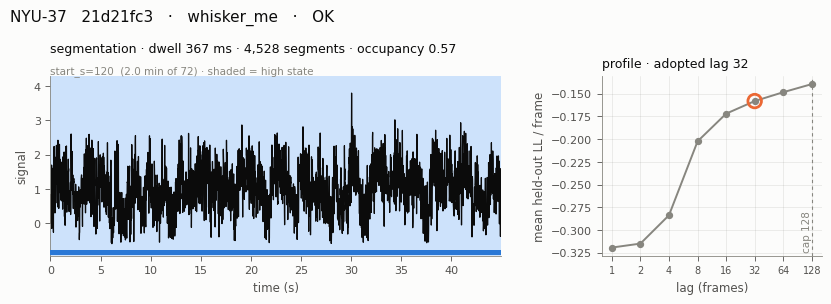

21d21fc3-4201-4edc-802a-c67b61952548


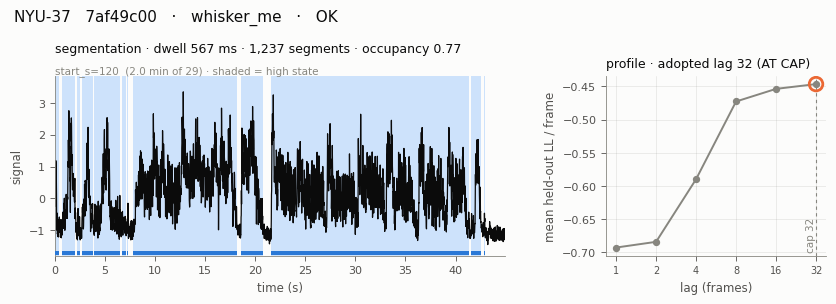

7af49c00-63dd-4fed-b2e0-1b3bd945b20b


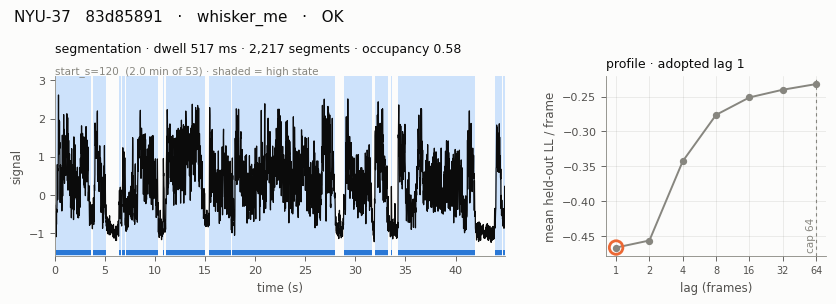

83d85891-bd75-4557-91b4-1cbb5f8bfc9d


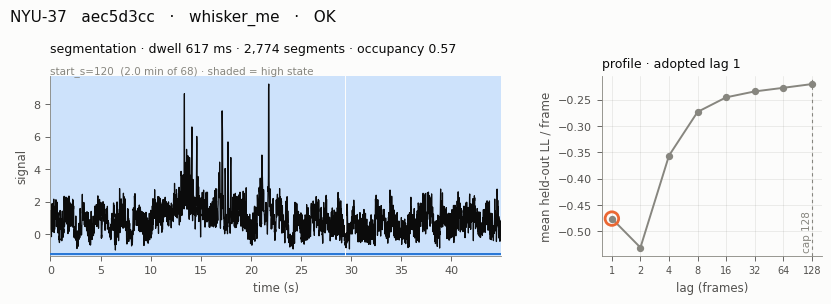

aec5d3cc-4bb2-4349-80a9-0395b76f04e2


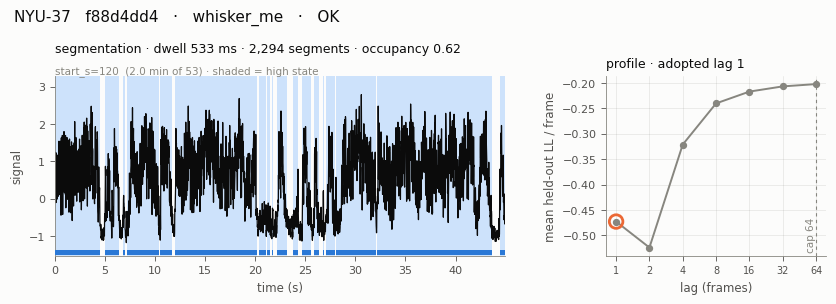

f88d4dd4-ccd7-400e-9035-fa00be3bcfa8


In [ ]:
only_flagged = False
n_show = 342
win_s = 45
start_s = 120      # applies to every session shown; None = auto-pick per session
compare_lag = 'legacy'   # 'legacy' = the lag your old code chose; or a number; or None

to_show = (df[~df.fit_ok] if only_flagged else df).head(n_show)
to_show = to_show.loc[to_show['mouse']=='NYU-37']

print(f'showing {len(to_show)} of {len(df)}')

for _, r in to_show.iterrows():
    try:
        fig, d = P.plot_session(save_path, data_path, var_interest,
                                mouse_name=r['mouse'], session=r['eid'],
                                zsc=zsc, num_train_batches=num_train_batches, fps=fps,
                                win_s=win_s, start_s=start_s, compare_lag=compare_lag,
                                legacy_path=legacy_path)
        plt.show()
        print(r['eid'])
    except FileNotFoundError as e:
        # a fit whose design matrix has since moved -- report it rather than dying
        print(f"{r['mouse']} {r['eid'][:8]}: {e}")

## Sessions to look at by eye

Everything that failed a screen, plus the ones sitting at the grid cap (where the cap,
not the data, ended the search).

In [ ]:
cols = [c for c in ['mouse', 'eid', 'best_lag', 'at_cap', 'cap', 'tau', 'median_dwell_ms',
                    'n_segments', 'occupancy_state1', 'bits_LL', 'n_folds_failed'] if c in df]

print('FLAGGED:')
display(df[~df.fit_ok][cols])

if 'at_cap' in df:
    print('AT CAP (candidates for a wider grid via extra_lags):')
    display(df[df.at_cap.fillna(False) & df.fit_ok][cols])

FLAGGED:


,mouse,eid,best_lag,at_cap,cap,tau,median_dwell_ms,n_segments,occupancy_state1,bits_LL,n_folds_failed
37,CSH_ZAD_019,7f6b86f9-879a-4ea2-8531-294a221af5d0,1,False,4,4.0,116.666667,28149,0.2867,1.224141,1
119,NYU-12,a8a8af78-16de-4841-ab07-fde4b5281a03,1,False,32,34.0,16.666667,71538,0.2209,0.879362,0
120,NYU-21,8c33abef-3d3e-4d42-9f27-445e9def08f9,8,True,8,8.0,116.666667,12160,0.2837,3.402560,0
163,PL017,1b61b7f2-a599-4e40-abd6-3e758d2c9e25,16,False,32,39.0,33.333333,80751,0.3098,0.680113,0
288,ZFM-01936,9b5a1754-ac99-4d53-97d3-35c2f6638507,64,True,64,62.0,150.000000,7144,0.4841,2.280156,0
289,ZFM-01936,d0ea3148-948d-4817-94f8-dcaf2342bbbe,64,True,64,67.0,150.000000,8183,0.4850,2.341712,0
291,ZFM-01937,113c5b6c-940e-4b21-b462-789b4c2be0e5,32,True,32,45.0,166.666667,8598,0.4894,2.026390,0


AT CAP (candidates for a wider grid via extra_lags):


,mouse,eid,best_lag,at_cap,cap,tau,median_dwell_ms,n_segments,occupancy_state1,bits_LL,n_folds_failed
4,CSHL045,fa704052-147e-46f6-b190-a65b837e605e,32,True,32,30.0,383.333333,8048,0.5853,1.422561,0
5,CSHL047,2d5f6d81-38c4-4bdc-ac3c-302ea4d5f46e,16,True,16,18.0,433.333333,7198,0.5832,1.301268,0
6,CSHL047,b52182e7-39f6-4914-9717-136db589706e,32,True,32,28.0,450.000000,5909,0.5446,1.385439,0
9,CSHL049,d2918f52-8280-43c0-924b-029b2317e62c,32,True,32,29.0,516.666667,5458,0.6320,1.156302,0
12,CSHL052,3663d82b-f197-4e8b-b299-7b803a155b84,32,True,32,27.0,583.333333,6303,0.4642,1.669505,0
...,...,...,...,...,...,...,...,...,...,...,...
334,ibl_witten_29,72028382-a869-4745-bacf-cb8789e16953,32,True,32,37.0,750.000000,4846,0.5373,1.488488,0
337,ibl_witten_29,af55d16f-0e31-4073-bdb5-26da54914aa2,32,True,32,43.0,466.666667,7413,0.4751,1.877461,0
339,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,64,True,64,77.0,500.000000,4054,0.4891,1.684155,0
340,ibl_witten_32,08102cfc-a040-4bcf-b63c-faa0f4914a6f,64,True,64,58.0,266.666667,8373,0.3336,1.889945,0
